#Question_9:
This question involves the use of multiple linear regression on the Auto data set.

In [63]:
import pandas as pd

data = pd.read_csv(r'C:\Users\user\OneDrive\Desktop\Course\ml\homework\Auto.csv')
#data = data.set_index('name')

mpg：每加侖英里數（miles per gallon），代表汽車的燃油效率。  
cylinders：汽缸數，表示引擎的汽缸數量。  
displacement：排氣量（立方英吋），指引擎氣缸能排出的總體積，通常反映引擎大小。  
horsepower：馬力，代表引擎輸出的動力。  
weight：車重（磅，pounds），表示汽車的總重量。  
acceleration：加速度，通常指從 0 加速到 60 英里所需的秒數。  
year：製造年份（通常是兩位數，例如 70 代表 1970 年）。  
origin：產地代碼（1 = 美國，2 = 歐洲，3 = 日本）。  
name：汽車名稱（品牌與型號，例如 “chevrolet chevelle malibu”）。  

#(a)
Produce a scatterplot matrix which includes all of the variables in the data set.

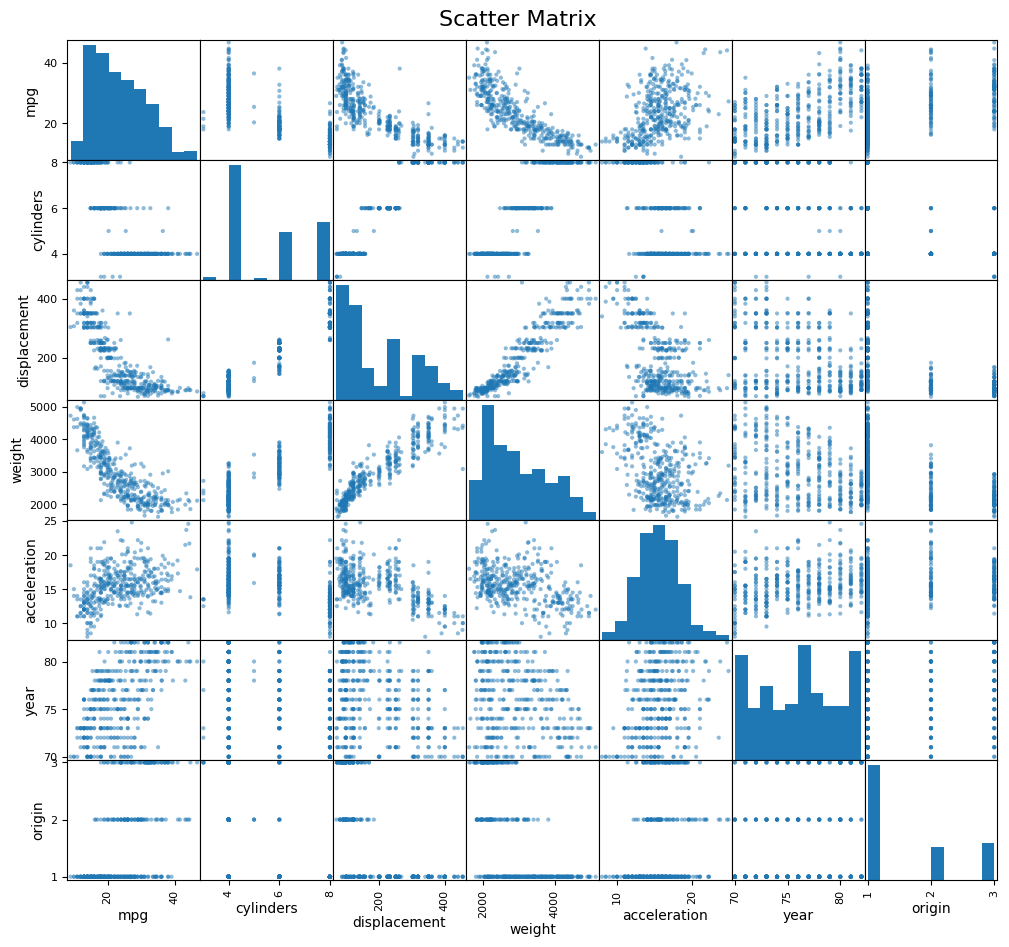

In [64]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots

pd.plotting.scatter_matrix(data, figsize=(12, 10))
plt.suptitle('Scatter Matrix', fontsize=16)
#pd.plotting.scatter_matrix(data)
plt.subplots_adjust(top=0.95)
plt.show()

#(b) 
Compute the matrix of correlations between the variables using the DataFrame.corr() method.

                 mpg  cylinders  displacement  weight  acceleration    year  \
mpg           1.0000    -0.7763       -0.8044 -0.8317        0.4223  0.5815   
cylinders    -0.7763     1.0000        0.9509  0.8970       -0.5041 -0.3467   
displacement -0.8044     0.9509        1.0000  0.9331       -0.5442 -0.3698   
weight       -0.8317     0.8970        0.9331  1.0000       -0.4195 -0.3079   
acceleration  0.4223    -0.5041       -0.5442 -0.4195        1.0000  0.2829   
year          0.5815    -0.3467       -0.3698 -0.3079        0.2829  1.0000   
origin        0.5637    -0.5650       -0.6107 -0.5813        0.2101  0.1843   

              origin  
mpg           0.5637  
cylinders    -0.5650  
displacement -0.6107  
weight       -0.5813  
acceleration  0.2101  
year          0.1843  
origin        1.0000  


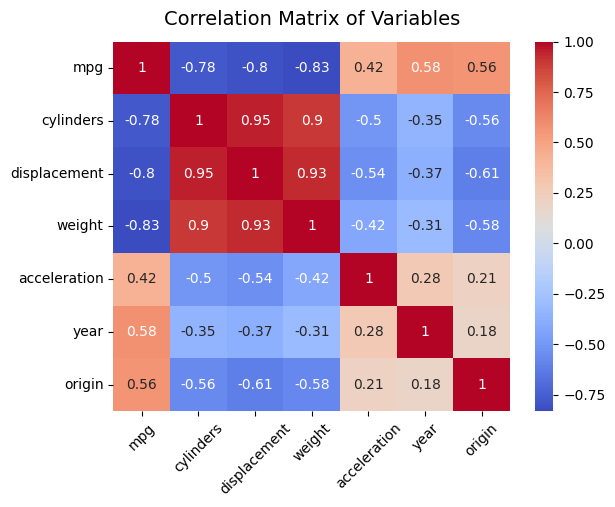

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = data.select_dtypes(include=['number']).corr()
print(corr_matrix)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Variables', fontsize=14, pad=12)
plt.xticks(rotation=45)
plt.show()

#(c) 
Use the sm.OLS() function to perform a multiple linear regression with mpg as the response and all other variables except name as the predictors.   
Use the summarize() function to print the results. Comment on the output. For instance:  
i. Is there a relationship between the predictors and the response? Use the anova_lm() function from statsmodels to answer this question.  
ii. Which predictors appear to have a statistically significant relationship to the response?  
iii. What does the coefficient for the year variable suggest?  

In [66]:
import statsmodels.api as sm

predictors = data.select_dtypes(include=['number'])

X = predictors.drop(columns=['mpg'])

X = sm.add_constant(X)
y = data['mpg']

model = sm.OLS(y, X)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     298.9
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          1.72e-142
Time:                        16:14:17   Log-Likelihood:                -1037.7
No. Observations:                 397   AIC:                             2089.
Df Residuals:                     390   BIC:                             2117.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -20.1358      4.145     -4.858   

In [67]:
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import pandas as pd
pd.set_option('display.float_format', '{:.4f}'.format)


formula = 'mpg ~ ' + ' + '.join([col for col in data.select_dtypes(include=['number']).columns if col != 'mpg'])
model_f = smf.ols(formula=formula, data=data).fit()
anova_results = anova_lm(model_f)
print(anova_results)


                   df     sum_sq    mean_sq         F  PR(>F)
cylinders      1.0000 14613.9450 14613.9450 1315.7969  0.0000
displacement   1.0000  1112.7553  1112.7553  100.1892  0.0000
weight         1.0000  1208.3882  1208.3882  108.7997  0.0000
acceleration   1.0000    61.1733    61.1733    5.5079  0.0194
year           1.0000  2642.4299  2642.4299  237.9167  0.0000
origin         1.0000   282.0694   282.0694   25.3967  0.0000
Residual     390.0000  4331.5489    11.1065       NaN     NaN


In [68]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF

vals = []
for i in range(1, X.values.shape[1]):
     vals.append(VIF(X.values, i))


vif_df = pd.DataFrame({
    'Variable': X.columns[1:],
    'VIF': vals
})

print(vif_df)

       Variable     VIF
0     cylinders 10.5907
1  displacement 20.0783
2        weight  8.5671
3  acceleration  1.6157
4          year  1.1817
5        origin  1.6626


#insights for question c:  
i. The coefficients of origin (1.3560), year (0.7703), and cylinders (-0.4198) are relatively large in magnitude, suggesting these variables have the greatest impact on mpg prediction.  
ii. Although cylinders shows a non-significant p-value (>0.05) in the regression summary, the ANOVA results reveal it contributes the most to the explained variance (highest F-value, lowest PR(>F)). This inconsistency is due to multicollinearity — cylinders is correlated with other predictors, making its unique effect hard to detect, even though it still strongly influences mpg overall. #multi-colline-arity  
iii. Specifically, the coefficient for the year is positive, indicating that the more recent a car's launch, the higher its MPG.   

#(d) 
Produce some of diagnostic plots of the linear regression fit as described in the lab.  
Comment on any problems you see with the fit.  
Do the residual plots suggest any unusually large outliers? Does the leverage plot identify any observations with unusually high leverage?

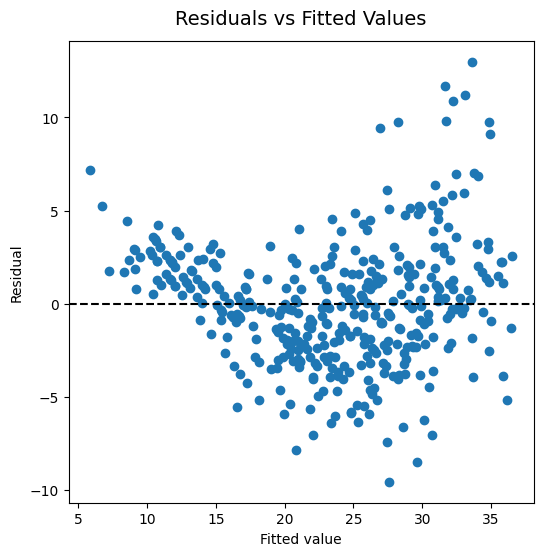

In [69]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.set_title('Residuals vs Fitted Values', fontsize=14, pad=12)
ax.axhline(0, c='k', ls='--')

#insights for question d:  
There is no clear pattern in this diagnostic plot, suggesting that the residuals are randomly distributed

np.int64(13)

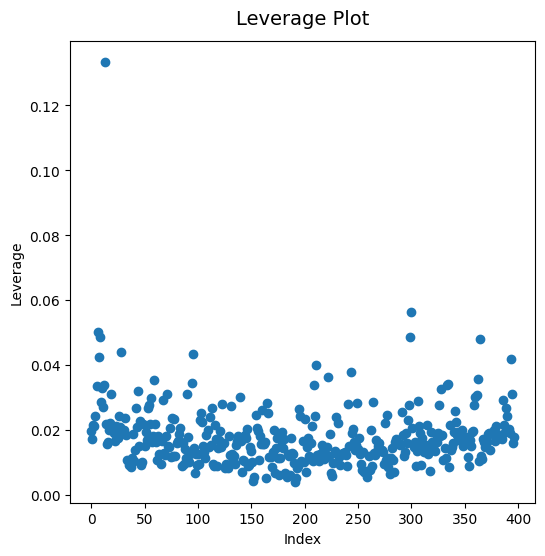

In [70]:
infl = results.get_influence()

ax = subplots(figsize=(6,6))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
ax.set_title('Leverage Plot', fontsize=14, pad=12)
np.argmax(infl.hat_matrix_diag)

#insights for question d:  
Based on the leverage plot, one observation with an index between 0 and 50 exhibits a substantially higher leverage (over 0.12) compared to the rest, which are all between 0 and 0.06. This indicates that this point has a disproportionate influence on the model fit and should be carefully examined for potential outlier effects.

#(e) 
Fit some models with interactions as described in the lab. Do any interactions appear to be statistically significant?

In [71]:
import pandas as pd
import statsmodels.formula.api as smf

formula = """
mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + C(origin)
      + cylinders:displacement
      + cylinders:horsepower
      + displacement:horsepower
"""

model = smf.ols(formula=formula, data=data).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.891
Method:                 Least Squares   F-statistic:                     20.88
Date:                Sun, 19 Oct 2025   Prob (F-statistic):           2.07e-85
Time:                        16:14:17   Log-Likelihood:                -834.21
No. Observations:                 397   AIC:                             1996.
Df Residuals:                     233   BIC:                             2650.
Df Model:                         163                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

#insights for question e:  
We aimed to better understand engine performance by including interaction terms among cylinders, displacement, and horsepower in the model. Based on the summary, the new model’s R-squared increased by 10%, reaching 93.6% compared to the original model. In addition, the interaction between cylinders and horsepower showed a significant impact on the predictions.

#(f) 
Try a few different transformations of the variables, such as log(X), X, X2. Comment on your findings.

In [72]:
import pandas as pd

data = data[data['horsepower'] != '?']

columns_to_check = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year']

skew_kurt = pd.DataFrame({
    'skewness': data[columns_to_check].skew(),
    'kurtosis': data[columns_to_check].kurtosis()
})

print(skew_kurt)


             skewness kurtosis
cylinders      0.5081  -1.3982
displacement   0.7017  -0.7783
horsepower     1.0873   0.6969
weight         0.5196  -0.8093
acceleration   0.2916   0.4442
year           0.0197  -1.1674


horsepower has the highest skewness, so we will apply a logarithmic transformation to it and a square transformation to acceleration.

In [76]:
import numpy as np

data1 = data.copy()

data1['horsepower'] = pd.to_numeric(data1['horsepower'], errors='coerce')

data1['horsepower_log'] = np.log(data1['horsepower'])
data1['acceleration_sq'] = data1['acceleration'] ** 2

In [77]:
import statsmodels.api as sm

X = data1[['cylinders', 'displacement', 'weight', 'year', 'horsepower_log', 'acceleration_sq']]
y = data1['mpg']

X_sm = sm.add_constant(X)

model_sm = sm.OLS(y, X_sm).fit()

print(model_sm.summary())


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     293.5
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          2.90e-140
Time:                        16:18:28   Log-Likelihood:                -1024.4
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     385   BIC:                             2091.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              20.6446      8.350     

#insights for question f:  
Based on the summary, horsepower_log can be confidently retained, as its p-value is well below 0.05. In contrast, the p-value for acceleration_sq is just below 0.05, so its effect is marginal and warrants further observation.